In [4]:
from google.colab import files

uploaded = files.upload()

Saving clean_population_data.csv to clean_population_data.csv


In [50]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load the cleaned CSV
df = pd.read_csv("clean_population_data.csv")

# Connect to SQLite (no installation required)
conn = sqlite3.connect("population.db")

# Push data to SQLite
df.to_sql("population_data", conn, index=False, if_exists="replace")

217

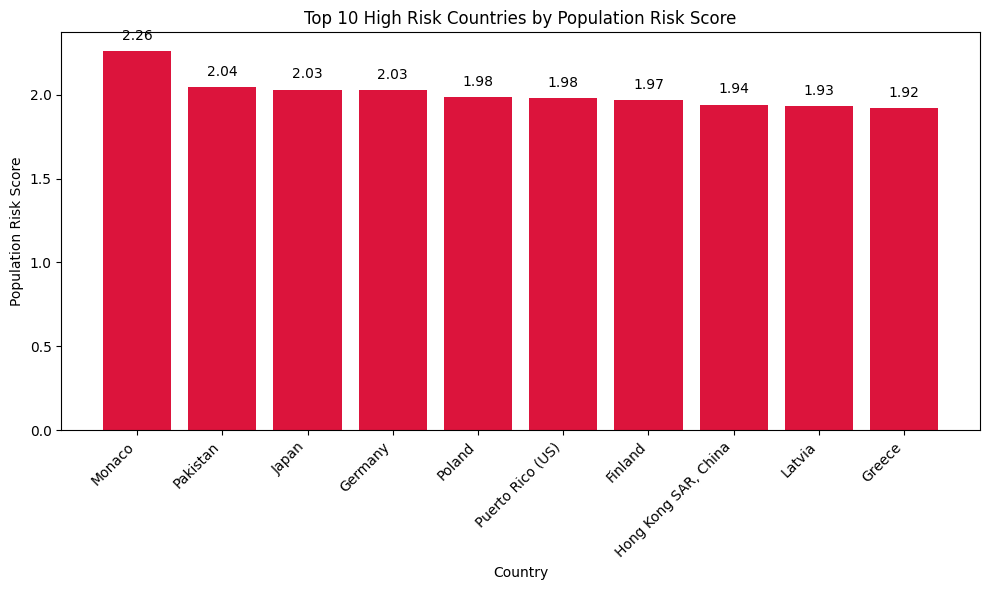

In [51]:
# Top 10 countries with the highest risk
High_Risk_Countries = """
SELECT country, population_risk_score
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;
"""
top_risk = pd.read_sql_query(High_Risk_Countries, conn)

# Make the bar chart
plt.figure(figsize=(10,6))
plt.bar(top_risk['country'], top_risk['population_risk_score'], color='crimson')

# Add labels and title
plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 High Risk Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')  # rotate x labels for readability

# Optional: add value labels on top of bars
for i, score in enumerate(top_risk['population_risk_score']):
    plt.text(i, score + 0.05, round(score, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

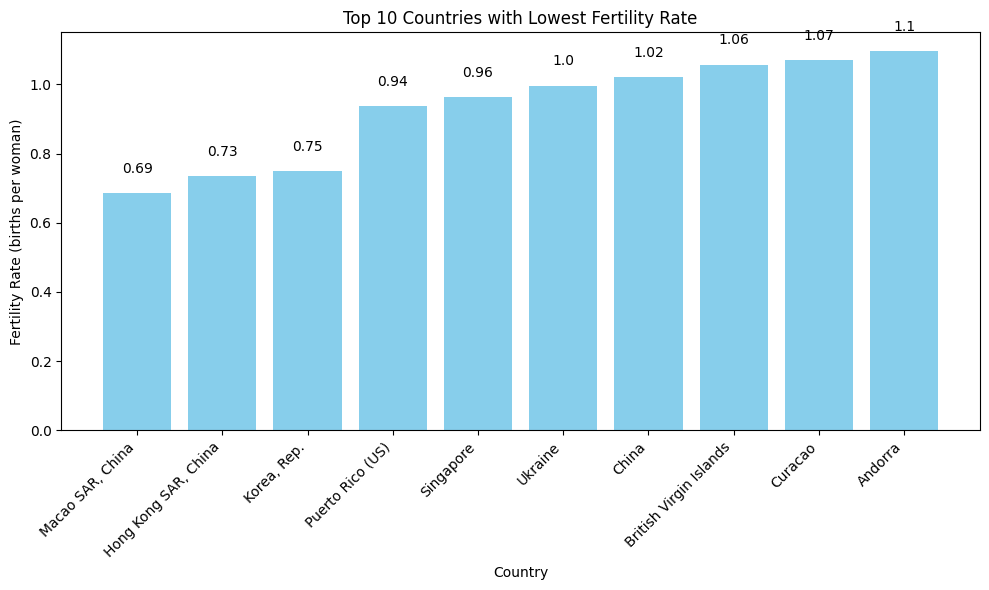

In [53]:
Low_Fertility_Rate = """SELECT country, fertility_rate
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;
"""
Low_fertility = pd.read_sql_query(Low_Fertility_Rate, conn)

# Bar chart for the 10 countries with lowest fertility rates
plt.figure(figsize=(10,6))
plt.bar(Low_fertility['country'], Low_fertility['fertility_rate'], color='skyblue')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("Top 10 Countries with Lowest Fertility Rate")
plt.xticks(rotation=45, ha='right')

# Add values on top of each bar
for i, rate in enumerate(Low_fertility['fertility_rate']):
    plt.text(i, rate + 0.05, round(rate, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

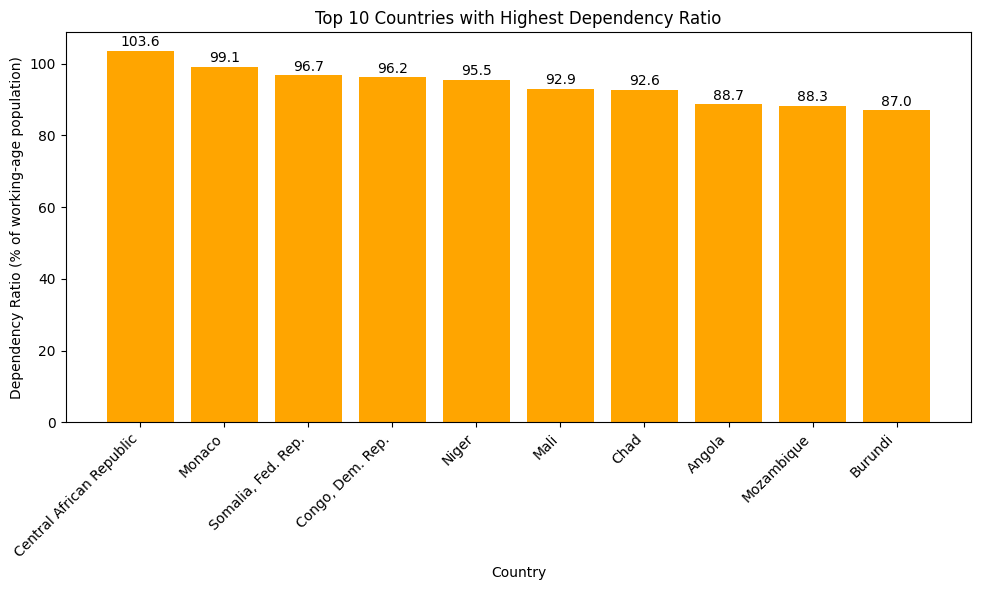

In [54]:
High_Dependency_Ratio = """SELECT country, dependency_ratio
FROM population_data
ORDER BY dependency_ratio DESC
LIMIT 10
"""

High_dependency = pd.read_sql_query(High_Dependency_Ratio, conn)

# Bar chart for countries with highest dependency ratio
plt.figure(figsize=(10,6))
plt.bar(High_dependency['country'], High_dependency['dependency_ratio'], color='orange')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Dependency Ratio (% of working-age population)")
plt.title("Top 10 Countries with Highest Dependency Ratio")
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for i, ratio in enumerate(High_dependency['dependency_ratio']):
    plt.text(i, ratio + 0.5, round(ratio, 1), ha='center', va='bottom')

plt.tight_layout()
plt.show()

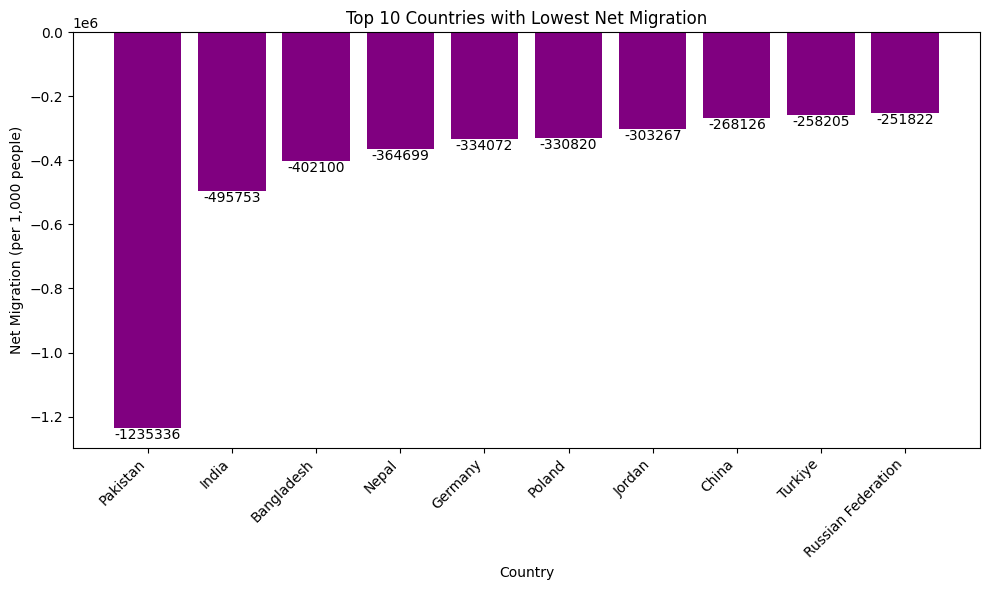

In [55]:
Low_migration = """SELECT country, net_migration
FROM population_data
WHERE net_migration < 0
ORDER BY net_migration ASC
LIMIT 10"""

low_migration = pd.read_sql_query(Low_migration, conn)

# Bar chart for countries with lowest net migration
plt.figure(figsize=(10,6))
plt.bar(low_migration['country'], low_migration['net_migration'], color='purple')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Net Migration (per 1,000 people)")
plt.title("Top 10 Countries with Lowest Net Migration")
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for i, migration in enumerate(low_migration['net_migration']):
    plt.text(i, migration - 0.5, round(migration, 1), ha='center', va='top')  # negative numbers, so text above bar

plt.tight_layout()
plt.show()

In [22]:
average_population_risk = """
SELECT country, AVG(population_risk_score) AS average_risk
FROM population_data

"""
average_population_risk = pd.read_sql_query(average_population_risk, conn)

print(average_population_risk)

       country  average_risk
0  Afghanistan      1.712265


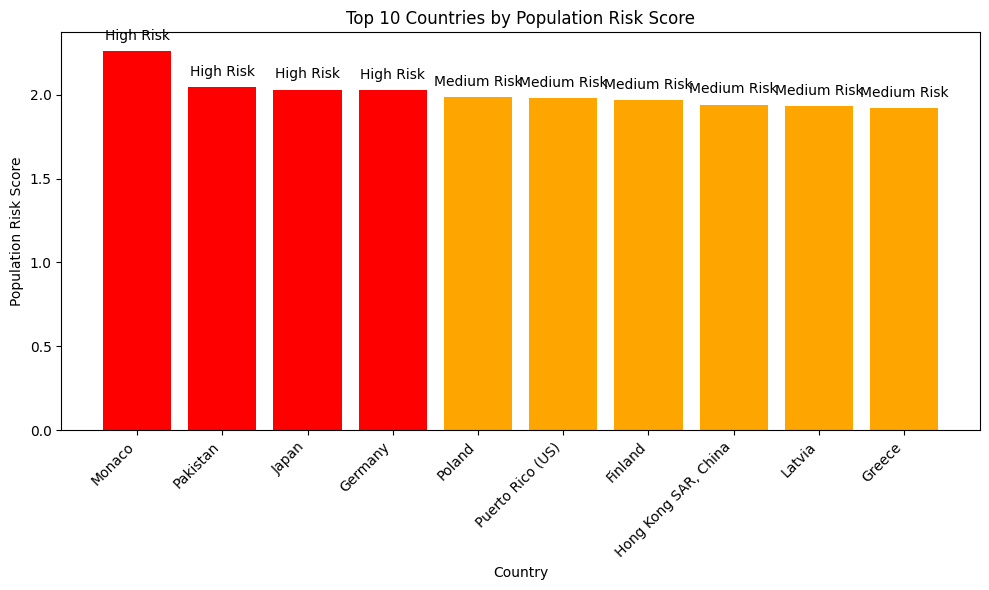

In [56]:
risk_score_categorization = """SELECT country,
       dependency_ratio,
       fertility_rate,
       net_migration,
       population_risk_score,
       CASE
           WHEN population_risk_score >= 2 THEN 'High Risk'
           WHEN population_risk_score >= 1.5 THEN 'Medium Risk'
           ELSE 'Low Risk'
       END AS risk_level
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

risk_score_categorization = pd.read_sql_query(risk_score_categorization, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
colors = {'High Risk':'red', 'Medium Risk':'orange', 'Low Risk':'green'}

plt.bar(risk_score_categorization['country'],
        risk_score_categorization['population_risk_score'],
        color=[colors[level] for level in risk_score_categorization['risk_level']])

plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')

# Add risk level labels above each bar
for i, score in enumerate(risk_score_categorization['population_risk_score']):
    plt.text(i, score + 0.05, risk_score_categorization['risk_level'][i], ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [44]:
fertility_replacement = """SELECT country,
       fertility_rate,
       CASE WHEN fertility_rate < 2.1 THEN 'Below Replacement' ELSE 'Above Replacement' END AS fertility_status
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;"""

fertility_replacement = pd.read_sql_query(fertility_replacement, conn)

print(fertility_replacement)

                  country  fertility_rate   fertility_status
0        Macao SAR, China           0.686  Below Replacement
1    Hong Kong SAR, China           0.735  Below Replacement
2             Korea, Rep.           0.749  Below Replacement
3        Puerto Rico (US)           0.937  Below Replacement
4               Singapore           0.963  Below Replacement
5                 Ukraine           0.997  Below Replacement
6                   China           1.021  Below Replacement
7  British Virgin Islands           1.057  Below Replacement
8                 Curacao           1.070  Below Replacement
9                 Andorra           1.096  Below Replacement


In [45]:
largest_risk = """SELECT country,
       CASE
           WHEN dependency_ratio >= 60 THEN 'Dependency is main risk'
           WHEN fertility_rate < 2.1 THEN 'Low fertility is main risk'
           WHEN net_migration < 0 THEN 'Migration is main risk'
           ELSE 'No single factor dominates'
       END AS main_risk_factor
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

largest_risk = pd.read_sql_query(largest_risk, conn)

print(largest_risk)

                country            main_risk_factor
0                Monaco     Dependency is main risk
1              Pakistan     Dependency is main risk
2                 Japan     Dependency is main risk
3               Germany     Dependency is main risk
4                Poland  Low fertility is main risk
5      Puerto Rico (US)  Low fertility is main risk
6               Finland     Dependency is main risk
7  Hong Kong SAR, China  Low fertility is main risk
8                Latvia  Low fertility is main risk
9                Greece  Low fertility is main risk


In [49]:
df1['analysis_type'] = 'top_risk'
df2['analysis_type'] = 'Low-fertility_rate'
df3['analysis_type'] = 'High-dependency_ratio'
df4['analysis_type'] = 'Low-migration'
df5['analysis_type'] = 'average_population_risk'
df6['analysis_type'] = 'risk_score_categorization'
df7['analysis_type'] = 'fertility_replacement'
df8['analysis_type'] = 'largest_risk'
# repeat for all 8 queries

df_all = pd.concat([df1, df2, df3, ...], ignore_index=True)
df_all.to_csv("all_query_results.csv", index=False)

NameError: name 'df1' is not defined